In [ ]:
# 数据处理
import pandas as pd
import numpy as np

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 机器学习
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [6]:
df = df.dropna(subset=['CustomerID'])

In [9]:
df = df[df['Quantity']>0]

In [11]:
df['TotalPrice'] = (
    df['Quantity'] *
    df['UnitPrice']
)

In [12]:
import datetime

analysis_date = df['InvoiceDate'].max()+datetime.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate':
    lambda x:(analysis_date-x.max()).days,

    'InvoiceNo':
    'nunique',

    'TotalPrice':
    'sum'

})


rfm.columns=[
    'Recency',
    'Frequency',
    'Monetary'
]


rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [13]:
rfm['Churn']=0


rfm.loc[
    rfm['Recency']>90,
    'Churn'
]=1


rfm.head()

,Recency,Frequency,Monetary,Churn
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


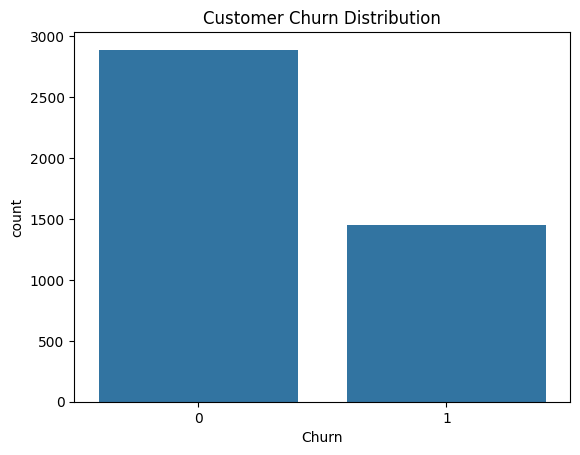

In [14]:
rfm['Churn'].value_counts()
sns.countplot(
    x='Churn',
    data=rfm
)

plt.title(
    "Customer Churn Distribution"
)

plt.show()

In [15]:
X = rfm[
[
'Recency',
'Frequency',
'Monetary'
]
]


y = rfm['Churn']
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)
model = LogisticRegression()


model.fit(
    X_train_scaled,
    y_train
)
y_pred = model.predict(
    X_test_scaled
)
print(
classification_report(
    y_test,
    y_pred
)
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       569
           1       1.00      0.98      0.99       299

    accuracy                           0.99       868
   macro avg       1.00      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



In [16]:
y_prob=model.predict_proba(
    X_test_scaled
)[:,1]


roc_auc_score(
    y_test,
    y_prob
)

np.float64(1.0)

In [17]:
coef=pd.DataFrame({

'feature':
X.columns,

'importance':
model.coef_[0]

})


coef

,feature,importance
0,Recency,11.443000
1,Frequency,0.223281
2,Monetary,-0.535629


In [18]:
rfm_scaled=scaler.transform(
    rfm[
    [
    'Recency',
    'Frequency',
    'Monetary'
    ]
    ]
)


rfm['Churn_probability']=(
    model.predict_proba(rfm_scaled)[:,1]
)
high_risk = rfm.sort_values(
    'Churn_probability',
    ascending=False
)
coupon_users = high_risk.head(100)
coupon_users.to_csv(
"high_risk_users.csv"
)

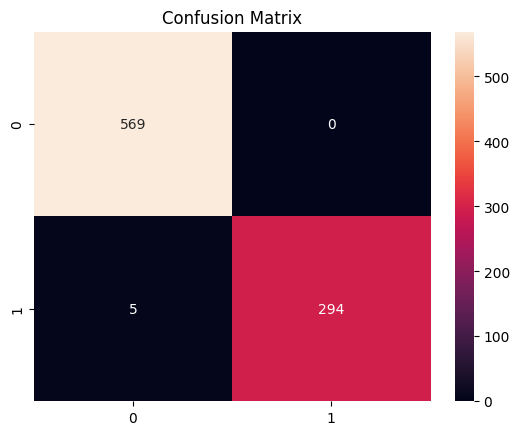

In [19]:
cm=confusion_matrix(
y_test,
y_pred
)


sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.title(
"Confusion Matrix"
)

plt.savefig(
"confusion_matrix.png"
)

plt.show()

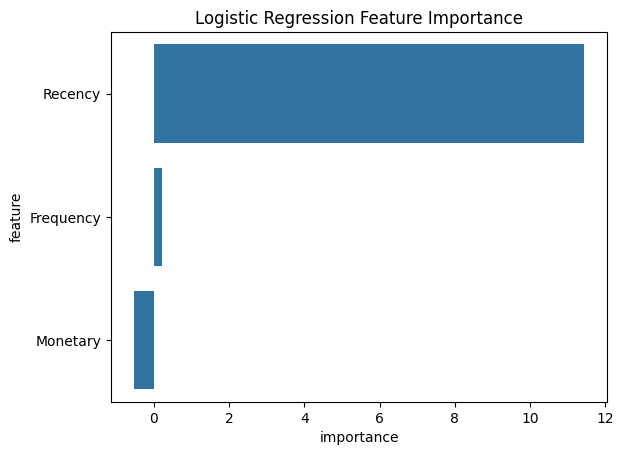

In [20]:
sns.barplot(
data=coef,
x='importance',
y='feature'
)


plt.title(
"Logistic Regression Feature Importance"
)


plt.savefig(
"feature_importance.png"
)

In [21]:
print(df.shape)
print(rfm.shape)
rfm.head()

(397924, 9)
(4339, 5)


,Recency,Frequency,Monetary,Churn,Churn_probability
CustomerID,,,,,
12346.0,326,1,77183.60,1,1.000000
12347.0,2,7,4310.00,0,0.000024
12348.0,75,4,1797.24,0,0.102537
12349.0,19,1,1757.55,0,0.000167
12350.0,310,1,334.40,1,1.000000


In [22]:
rfm['Churn'].value_counts()

,count
Churn,
0,2890
1,1449


In [23]:
print(
classification_report(
    y_test,
    y_pred
)
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       569
           1       1.00      0.98      0.99       299

    accuracy                           0.99       868
   macro avg       1.00      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



In [24]:
print(
roc_auc_score(
    y_test,
    y_prob
)
)

1.0


In [25]:
confusion_matrix(
    y_test,
    y_pred
)

array([[569,   0],
       [  5, 294]])

In [26]:
coef

,feature,importance
0,Recency,11.443000
1,Frequency,0.223281
2,Monetary,-0.535629


In [27]:
coupon_users.columns

Index(['Recency', 'Frequency', 'Monetary', 'Churn', 'Churn_probability'], dtype='object')

In [28]:
coupon_users.head(10)

,Recency,Frequency,Monetary,Churn,Churn_probability
CustomerID,,,,,
17850.0,372,34,5391.21,1,1.0
13747.0,374,1,79.60,1,1.0
16583.0,374,1,233.45,1,1.0
17908.0,374,1,243.28,1,1.0
12791.0,374,1,192.60,1,1.0
17968.0,374,1,277.35,1,1.0
14729.0,374,1,313.49,1,1.0
18074.0,374,1,489.60,1,1.0
16048.0,373,2,256.44,1,1.0
